# Preambolo


In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
import uncertainties.umath as unm
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio
%cd Oscillazioni smorzate e forzate

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1570, done.
remote: Counting objects: 100% (477/477), done.
remote: Compressing objects: 100% (311/311), done.
remote: Total 1570 (delta 236), reused 394 (delta 157), pack-reused 1093 (from 1)
Receiving objects: 100% (1570/1570), 21.41 MiB | 36.97 MiB/s, done.
Resolving deltas: 100% (806/806), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio
/content/Esperienze-in-laboratorio/Oscillazioni smorzate e forzate


In [ ]:
!git pull

Already up to date.


# Oscillazioni Libere

In [ ]:
print("="*70)
ω0 = ufloat(2.57, 0.05)
T0 = 2*np.pi/ω0
print(f"Il valore di ω0 per oscillazioni libere è: {ω0:.3P} rad/s")
print(f"Il valore di T0 per oscillazioni libere è: {T0:.3P} s")
print("="*70)

Il valore di ω0 per oscillazioni libere è: 2.57±0.05 rad/s
Il valore di T0 per oscillazioni libere è: 2.44±0.05 s


#Oscillazioni Smorzate 4mm

In [ ]:
df=pd.read_excel('Oscillazioni smorzate e forzate.xlsx', sheet_name=0)
df=df.fillna('')
df

,γ,sγ,ω,sω,ω0 [rad/s],Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,0.295,0.012,2.49,0.01,2.474978,,,,,,
1,0.302,0.015,2.45,0.013,(ω0)/2 [rad/s],,,,,,
2,0.297,0.011,2.45,0.01,1.237489,,,,,,
3,0.242,0.014,2.44,0.013,2(ω0) [rad/s],,,,,,
4,0.282,0.012,2.45,0.011,4.949956,,,,,,
5,γ_best,σx_best,ω_best,σx_best,,,,,,,
6,0.285125,0.005617,2.4585,0.004994,,,,,,,
7,γ_medio,Err.Media,ω_medio,Err.Media,,,,,,,
8,0.2836,0.010911,2.456,0.008718,,,,,,,
9,,,,,,,,,,,


In [ ]:
ω1_best = ufloat(df.iloc[6, 2], df.iloc[6, 3])
γ1_best = ufloat(df.iloc[6, 0], df.iloc[6, 1])
ω0_1best = unp.sqrt(ω1_best**2+γ1_best**2)

print("="*70)
print(f"Il valore di ω_best è: {ω1_best:.4P} rad/s")
print(f"Il valore di γ_best è: {γ1_best:.4P}")
print(f"Il valore di ω0_best è: {ω0_1best:.4P} rad/s")
print("="*70)
t_test(ω0_1best, ω0, nome1="ω0_best", nome2="ω0");
print("="*70)

Il valore di ω_best è: 2.458±0.005 rad/s
Il valore di γ_best è: 0.2851±0.0056
Il valore di ω0_best è: 2.475±0.005 rad/s
Test di compatibilità tra ω0_best e ω0: |t| = 1.8909953


In [ ]:
ω1_ = ufloat(df.iloc[8, 2], df.iloc[8, 3])
γ1_ = ufloat(df.iloc[8, 0], df.iloc[8, 1])
ω0_1 = unp.sqrt(ω1_**2+γ1_**2)

print("="*70)
print(f"Il valore di ω_medio è: {ω1_:.4P} rad/s")
print(f"Il valore di γ_medio è: {γ1_:.4P}")
print(f"Il valore di ω0_medio è: {ω0_1:.4P} rad/s")
print("="*70)
t_test(ω0_1, ω0, nome1="ω0_medio", nome2="ω0");
print("="*70)

Il valore di ω_medio è: 2.456±0.009 rad/s
Il valore di γ_medio è: 0.2836±0.0109
Il valore di ω0_medio è: 2.472±0.009 rad/s
Test di compatibilità tra ω0_medio e ω0: |t| = 1.9243589


# Oscillazioni Smorzate e Forzate 4mm


      ESITO DEL FIT OTTIMIZZATO
M0:      1.1432e+01 ± 2.0544e-01
omega0:  2.6159 ± 0.0088 rad/s
gamma:   0.3735 ± 0.0264 rad/s
omega_res:   2.6159 rad/s
Il risultato del test del χ² è:
  χ²               = 0.37449349
  Gradi di libertà = 6
  χ² ridotto       = 0.062415582
  Il p-value associato è: 0.99904854


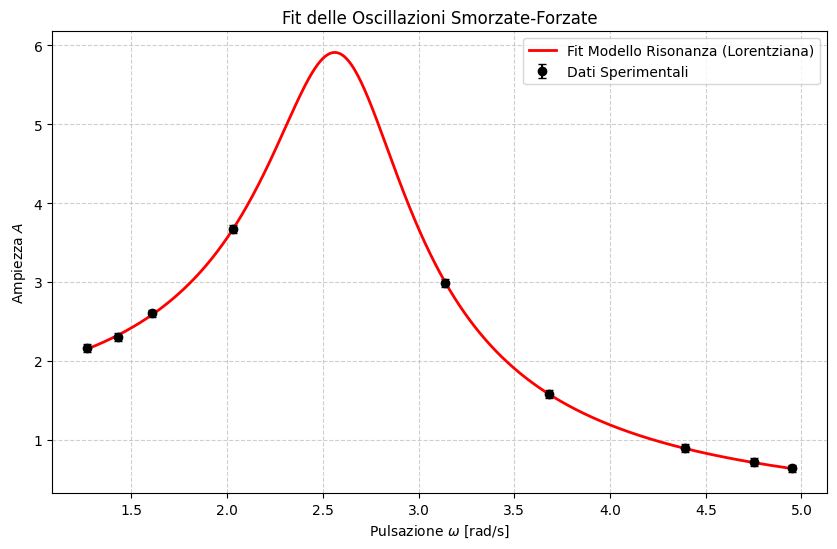

In [ ]:
x1 = unp.uarray(df.iloc[11:20, 1], df.iloc[11:20, 2])
y1 = unp.uarray(df.iloc[11:20, 9], df.iloc[11:20, 10])

x_data1 = unp.nominal_values(x1)
y_data1 = unp.nominal_values(y1)
sigmas1 = unp.std_devs(y1)

def resonance_model(omega, M0, omega0, gamma):
    """
    Modello dell'ampiezza per oscillazioni forzate.
    omega: pulsazione della forzante (asse x)
    M0: costante legata alla forza esterna
    omega0: pulsazione naturale del sistema
    gamma: coefficiente di smorzamento
    """
    diff_quad = (omega0**2 - omega**2)**2
    smorzamento = 4 * (gamma**2) * (omega**2)
    return M0 / np.sqrt(diff_quad + smorzamento)

f_peak = x_data1[np.argmax(y_data1)]

p0 = [11, f_peak, 0.3]

try:
    popt1, pcov1 = sp.optimize.curve_fit(
        resonance_model,
        x_data1,
        y_data1,
        p0=p0,
        sigma=sigmas1,
        absolute_sigma=True,
        bounds=(0, np.inf)
    )

    M0_1fit, o0_1fit, g_1fit = popt1
    errors = np.sqrt(np.diag(pcov1))

    print("\n" + "="*40)
    print("      ESITO DEL FIT OTTIMIZZATO")
    print("="*40)
    print(f"M0:      {M0_1fit:.4e} ± {errors[0]:.4e}")
    print(f"omega0:  {o0_1fit:.4f} ± {errors[1]:.4f} rad/s")
    print(f"gamma:   {g_1fit:.4f} ± {errors[2]:.4f} rad/s")
    print(f"omega_res:   {o0_1fit:.4f} rad/s")
    print("="*40)

    y_attesi = resonance_model(x_data1, M0_1fit, o0_1fit, g_1fit)
    chi_quadro(y_data1, y_attesi, sigmas1, n_parametri=3)

    print("="*40)

    plt.figure(figsize=(10, 6))

    plt.errorbar(x_data1, y_data1, yerr=sigmas1, fmt='o', color='black',
                 label='Dati Sperimentali', markersize=6, capsize=3)

    x_fine = np.linspace(min(x_data1), max(x_data1), 1000)
    plt.plot(x_fine, resonance_model(x_fine, *popt1), 'r-', label='Fit Modello Risonanza (Lorentziana)', lw=2)

    plt.xlabel('Pulsazione $\\omega$ [rad/s]')
    plt.ylabel('Ampiezza $A$')
    plt.title('Fit delle Oscillazioni Smorzate-Forzate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

except Exception as e:
    print(f"\nErrore durante il fit: {e}")

In [ ]:
ω0_fit1 = ufloat(o0_1fit, errors[1])
γ_fit1 = ufloat(g_1fit, errors[2])

print("="*70)
t_test(ω0_fit1, ω0, nome1="ω0_fit1", nome2="ω0");
t_test(ω0_fit1, ω0_1, nome1="ω0_fit1", nome2="ω0_medio");
t_test(ω0_fit1, ω0_1best, nome1="ω0_fit1", nome2="ω0_best");
print("="*70)
t_test(γ_fit1, γ1_, nome1="γ_fit1", nome2="γ_medio");
t_test(γ_fit1, γ1_best, nome1="γ_fit1", nome2="γ_best");
print("="*70)

Test di compatibilità tra ω0_fit1 e ω0: |t| = 0.90349247
Test di compatibilità tra ω0_fit1 e ω0_medio: |t| = 11.552173
Test di compatibilità tra ω0_fit1 e ω0_best: |t| = 13.891043
Test di compatibilità tra γ_fit1 e γ_medio: |t| = 3.1414821
Test di compatibilità tra γ_fit1 e γ_best: |t| = 3.2678248


# Oscillazioni Smorzate 5mm


In [ ]:
df1=pd.read_excel('Oscillazioni smorzate e forzate.xlsx', sheet_name=1)
df1=df1.fillna('')
df1

,γ,sγ,ω,sω,ω0 [rad/s],Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,0.256,0.0046,2.57,0.0044,2.621067,,,,,,
1,0.267,0.0021,2.59,0.0019,(ω0)/2 [rad/s],,,,,,
2,0.274,0.0006,2.61,0.0007,1.310534,,,,,,
3,γ_best,σx_best,ω_best,σx_best,2(ω0) [rad/s],,,,,,
4,0.273201,0.000572,2.60679,0.00065,5.242134,,,,,,
5,γ_medio,Err.Media,ω_medio,Err.Media,,,,,,,
6,0.265667,0.005239,2.59,0.011547,,,,,,,
7,,,,,,,,,,,
8,Tensione [V],ω interp. [rad/s],sω [rad/s],T [s],T_f [s],,,T_f medio [s],ω-f [rad/s],A,σA
9,1.8,1.31,0.01,4.796325,4.84,4.74,4.82,4.8,1.308997,2.21,0.05


In [ ]:
ω2_best = ufloat(df1.iloc[4, 2], df1.iloc[4, 3])
γ2_best = ufloat(df1.iloc[4, 0], df1.iloc[4, 1])
ω0_2best = unp.sqrt(ω2_best**2+γ2_best**2)

print("="*70)
print(f"Il valore di ω_best è: {ω2_best:.4P} rad/s")
print(f"Il valore di γ_best è: {γ2_best:.4P}")
print(f"Il valore di ω0_best è: {ω0_2best:.4P} rad/s")
print("="*70)
t_test(ω0_2best, ω0, nome1="ω0_best", nome2="ω0");
print("="*70)

Il valore di ω_best è: 2.607±0.001 rad/s
Il valore di γ_best è: 0.2732±0.0006
Il valore di ω0_best è: 2.621±0.001 rad/s
Test di compatibilità tra ω0_best e ω0: |t| = 1.0212547


In [ ]:
ω2_ = ufloat(df1.iloc[6, 2], df1.iloc[6, 3])
γ2_ = ufloat(df1.iloc[6, 0], df1.iloc[6, 1])
ω0_2 = unp.sqrt(ω2_**2+γ2_**2)

print("="*70)
print(f"Il valore di ω_best è: {ω2_:.4P} rad/s")
print(f"Il valore di γ_best è: {γ2_:.4P}")
print(f"Il valore di ω0_best è: {ω0_2:.4P} rad/s")
print("="*70)
t_test(ω0_2, ω0, nome1="ω0_medio", nome2="ω0");
print("="*70)

Il valore di ω_best è: 2.590±0.012 rad/s
Il valore di γ_best è: 0.2657±0.0052
Il valore di ω0_best è: 2.604±0.011 rad/s
Test di compatibilità tra ω0_medio e ω0: |t| = 0.65470066


# Oscillazioni Smorzate e Forzate 5mm



      ESITO DEL FIT OTTIMIZZATO
M0:      1.1493e+01 ± 2.2926e-01
omega0:  2.6263 ± 0.0097 rad/s
gamma:   0.2637 ± 0.0589 rad/s
omega_res:   2.6263 rad/s
Il risultato del test del χ² è:
  χ²               = 0.15088446
  Gradi di libertà = 7
  χ² ridotto       = 0.021554923
  Il p-value associato è: 0.99999044


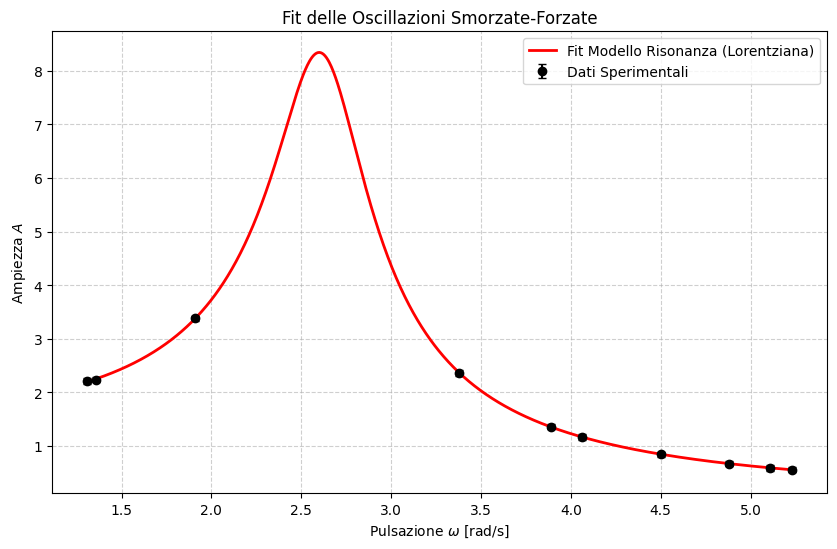

In [ ]:
x2 = unp.uarray(df1.iloc[9:19, 1], df1.iloc[9:19, 2])
y2 = unp.uarray(df1.iloc[9:19, 9], df1.iloc[9:19, 10])

x_data2 = unp.nominal_values(x2)
y_data2 = unp.nominal_values(y2)
sigmas2 = unp.std_devs(y2)

f_peak = x_data2[np.argmax(y_data2)]
p0 = [11, f_peak, 0.3]

try:
    popt2, pcov2 = sp.optimize.curve_fit(
        resonance_model,
        x_data2,
        y_data2,
        p0=p0,
        sigma=sigmas2,
        absolute_sigma=True,
        bounds=(0, np.inf)
    )

    M0_2fit, o0_2fit, g_2fit = popt2
    errors = np.sqrt(np.diag(pcov2))

    print("\n" + "="*40)
    print("      ESITO DEL FIT OTTIMIZZATO")
    print("="*40)
    print(f"M0:      {M0_2fit:.4e} ± {errors[0]:.4e}")
    print(f"omega0:  {o0_2fit:.4f} ± {errors[1]:.4f} rad/s")
    print(f"gamma:   {g_2fit:.4f} ± {errors[2]:.4f} rad/s")
    print(f"omega_res:   {o0_2fit:.4f} rad/s")
    print("="*40)

    y_attesi = resonance_model(x_data2, M0_2fit, o0_2fit, g_2fit)
    chi_quadro(y_data2, y_attesi, sigmas2, n_parametri=3)

    print("="*40)

    plt.figure(figsize=(10, 6))

    plt.errorbar(x_data2, y_data2, yerr=sigmas2, fmt='o', color='black',
                 label='Dati Sperimentali', markersize=6, capsize=3)

    x_fine = np.linspace(min(x_data2), max(x_data2), 1000)
    plt.plot(x_fine, resonance_model(x_fine, *popt2), 'r-', label='Fit Modello Risonanza (Lorentziana)', lw=2)

    plt.xlabel('Pulsazione $\\omega$ [rad/s]')
    plt.ylabel('Ampiezza $A$')
    plt.title('Fit delle Oscillazioni Smorzate-Forzate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

except Exception as e:
    print(f"\nErrore durante il fit: {e}")

In [ ]:
ω0_fit2 = ufloat(o0_2fit, errors[1])
γ_fit2 = ufloat(g_2fit, errors[2])

print("="*70)
t_test(ω0_fit2, ω0, nome1="ω0_fit2", nome2="ω0");
t_test(ω0_fit2, ω0_2, nome1="ω0_fit2", nome2="ω0_medio");
t_test(ω0_fit2, ω0_2best, nome1="ω0_fit2", nome2="ω0_best");
print("="*70)
t_test(ω0_fit1, ω0_fit2, nome1="ω0_fit1", nome2="ω0_fit2");
print("="*70)
t_test(γ_fit2, γ2_, nome1="γ_fit2", nome2="γ_medio");
t_test(γ_fit2, γ2_best, nome1="γ_fit2", nome2="γ_best");
print("="*70)

Test di compatibilità tra ω0_fit2 e ω0: |t| = 1.1047252
Test di compatibilità tra ω0_fit2 e ω0_medio: |t| = 1.5094624
Test di compatibilità tra ω0_fit2 e ω0_best: |t| = 0.53618559
Test di compatibilità tra ω0_fit1 e ω0_fit2: |t| = 0.79383105
Test di compatibilità tra γ_fit2 e γ_medio: |t| = 0.033129309
Test di compatibilità tra γ_fit2 e γ_best: |t| = 0.16116239


# Confronto Curve di Risonanza

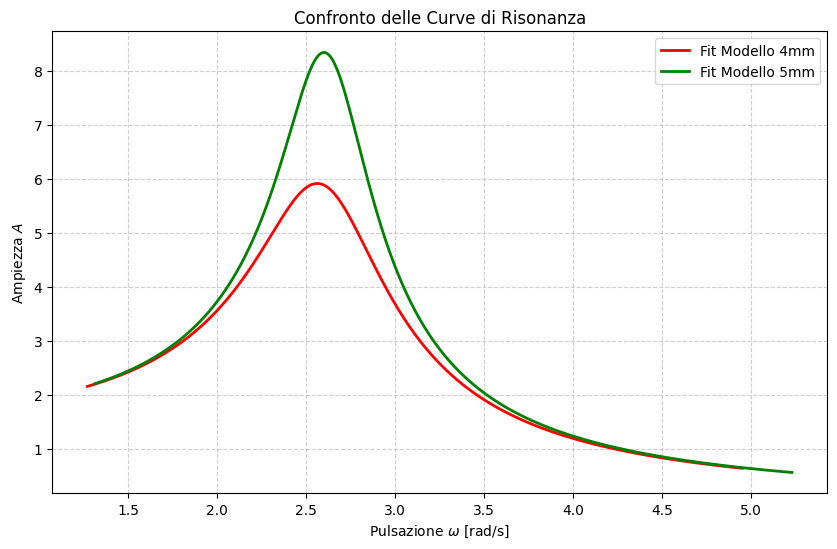

In [ ]:
# =====================================================================
# GRAFICO DI CONFRONTO
# =====================================================================
plt.figure(figsize=(10, 6))

# --- Curva di Fit 4mm - Linea Rossa ---
x_fine1 = np.linspace(min(x_data1), max(x_data1), 1000)
plt.plot(
    x_fine1,
    resonance_model(x_fine1, *popt1),
    "r-",
    label="Fit Modello 4mm",
    lw=2,
)

# --- Curva di Fit Set 5mm - Linea Verde ---
x_fine2 = np.linspace(min(x_data2), max(x_data2), 1000)
plt.plot(
    x_fine2,
    resonance_model(x_fine2, *popt2),
    "g-",
    label="Fit Modello 5mm",
    lw=2,
)

# --- Assi e Legenda ---
plt.xlabel("Pulsazione $\\omega$ [rad/s]")
plt.ylabel("Ampiezza $A$")
plt.title("Confronto delle Curve di Risonanza")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()